In [3]:
import sys
import os
sys.path.append(os.path.abspath('../..'))


# from scan_engine.status_fields_config_24summ import STATUS_FIELDS_CONFIG
from status_fields_config_oct3v1_brws_250523 import STATUS_FIELDS_CONFIG

from utlis.scan_engine_utlis.scan_eng_big_utlis import log_folder_to_parquet_sep

if __name__ == "__main__":
    base_folder = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused" #'/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon' #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1" #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/24summ"  # Replace with your base folder
    # save_path = os.path.join(base_folder, 'paret')
    failed_paths_file = None #"/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/sync_failed.txt" #'/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1/sync_failed_brws.txt'  # File containing failed paths

    force_rescan_rec_files = [
        # ('2023-10-01', '001'),
        # ('2023-10-02', '002'),
        # Add more as needed
    ]
    rescan_threshold_days = 0.000001 # 7 days, but guess if i mess up i can just change it to automatically rescan all, smile... #0.1

    log_folder_to_parquet_sep(base_folder, failed_paths_file, STATUS_FIELDS_CONFIG,
                              force_rescan_rec_files=force_rescan_rec_files,
                              rescan_threshold_days=rescan_threshold_days)


PermissionError: [Errno 13] Failed to open local file '/hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4/folder_log.parquet'. Detail: [errno 13] Permission denied

In [3]:
sys.path.append(os.path.abspath('../..'))
from utlis.scan_engine_utlis.scan_engine_utlis import read_all_parquet_files
# base_folder = "/hpc/group/tdunn/Bryan_Rigs/BigOpenField/Oct3V1"
all_df = read_all_parquet_files(base_folder)

In [4]:
import pyarrow.compute as pc
from functools import reduce


table = all_df #combined_df
# Filter mir_generate_param == 0 and sync != 3
conditions = [
   pc.equal(table['mir_generate_param'], '0'),
#    pc.equal(table['sync'], '1'),
#    # pc.not_equal(table['sync'], '3'),
#    pc.equal(table['com'], '0'),
#    pc.equal(table['com_vis'], '1'),
   # # pc.equal(table['v1'], '1'),
#    pc.equal(table['dannce'], '0'),
   # pc.equal(table['dannce_vis'], '1'),
   # pc.equal(table['social'], '1'),
   # pc.equal(table['mini_6cam_map'], '1'),
   # pc.equal(table['mini_rec_sync_com'], '1'),
   #mini_rec_sync
   # mini_6cam_map
]

filter_mask = reduce(pc.and_, conditions)



# Apply the filter and print the results
for_com = table.filter(filter_mask)

# Print each row of the filtered table
print(for_com.to_pandas())  # This will display the filtered data in a familiar pandas-like format


  mir_generate_param sync mini_6cam_map dropf_handle com com_vis social  \
0                  0    0             0            0   0       0      1   
1                  0    0             0            0   0       0      1   
2                  0    0             0            0   0       0      1   
3                  0    0             0            0   0       0      1   
4                  0    0             0            0   0       0      1   

  miniscope test after_oxytocin before_oxytocin dannce dannce_vis  \
0         0    0              0               0      0          0   
1         0    0              0               0      0          0   
2         0    0              0               0      0          0   
3         0    0              0               0      0          0   
4         0    0              0               0      0          0   

  mini_rec_sync         rec_file                   scan_time  \
0             0  0single1_group1  2025-07-09T13:04:57.133322   
1     

In [7]:
# Convert and flatten the ChunkedArray
experiment_paths = for_com["rec_path"].to_pylist()

# Print each path
for path in experiment_paths:
    # Each element is likely a list with one string, e.g., ['/some/path']
    print(path[0] if isinstance(path, list) else path)


/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250407v1l23
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250407v1l23_2partnersocialpreference
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink_onlybehavior
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink_pblkconspecific
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250505v1l23r1pink_pnocapconspecific
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250506v1l23l1yellow
/hpc/group/tdunn/tdunn/Bryan_Rigs/BigOpenField/25juneon/2025_07_02/20250506v1l23l1yellow_pblkconspecific


In [5]:
from utlis.exe_engine_utlis.comb_all_exe import sequential_process_and_update_mirgenparam
filtered_table = for_com
sequential_process_and_update_mirgenparam(filtered_table, base_folder)

Found 6 calibration files.
Frame count: 13800
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/calib_before/hires_cam1_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/calib_before/hires_cam2_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/calib_before/hires_cam3_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/calib_before/hires_cam4_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/calib_before/hires_cam5_params.mat
Processed /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/calib_before/hires_cam6_params.mat
Data saved to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single1_group1/2025_07_01_0single1_group1_calib_before_label3d_dannce.mat
mir_gen

Processing: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single1_group1


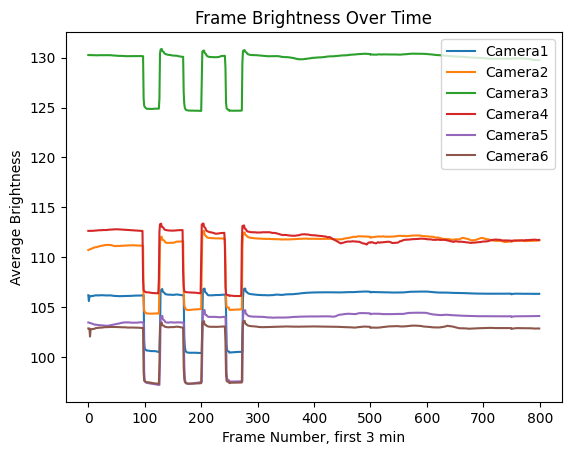

Saved brightness plot to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single1_group1/videos/6cam_sync.png
Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single1_group1: {'Camera1': [99, 170, 245], 'Camera2': [98, 169, 243, 244], 'Camera3': [98, 169, 244], 'Camera4': [97, 168, 243], 'Camera5': [99, 170, 245], 'Camera6': [98, 169, 244]}
Processed drop frames: {'Camera1': 99, 'Camera2': 98, 'Camera3': 98, 'Camera4': 97, 'Camera5': 99, 'Camera6': 98}
97
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single1_group1/df_synced_2025_07_01_0single1_group1_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single1_group1 with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single1_group1/2025_07_01_0s

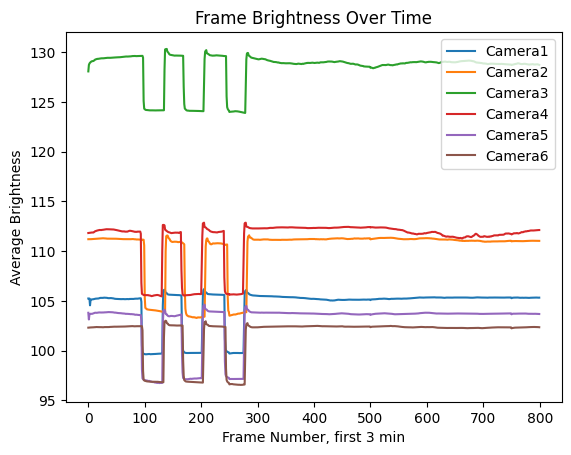

Saved brightness plot to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single2_group2/videos/6cam_sync.png
Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single2_group2: {'Camera1': [95, 166, 242], 'Camera2': [100, 171, 247], 'Camera3': [98, 169, 245], 'Camera4': [94, 165, 241], 'Camera5': [95, 166, 242], 'Camera6': [97, 168, 244]}
Processed drop frames: {'Camera1': 95, 'Camera2': 100, 'Camera3': 98, 'Camera4': 94, 'Camera5': 95, 'Camera6': 97}
94
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single2_group2/df_synced_2025_07_01_0single2_group2_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single2_group2 with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single2_group2/2025_07_01_0sing

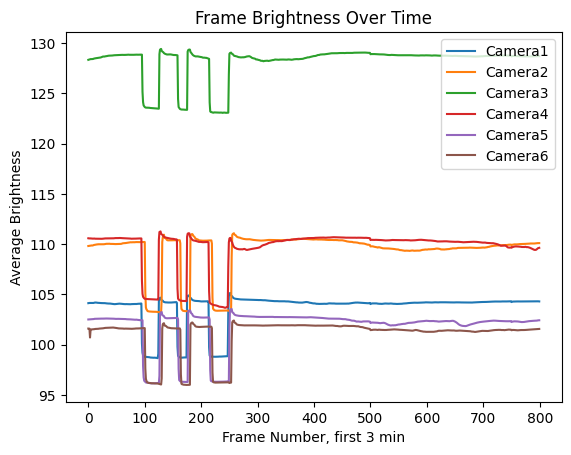

Saved brightness plot to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single3_group3/videos/6cam_sync.png
Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single3_group3: {'Camera1': [95, 158, 214], 'Camera2': [101, 164, 220], 'Camera3': [96, 159, 215], 'Camera4': [95, 158, 214], 'Camera5': [97, 160, 216], 'Camera6': [101, 164, 220]}
Processed drop frames: {'Camera1': 95, 'Camera2': 101, 'Camera3': 96, 'Camera4': 95, 'Camera5': 97, 'Camera6': 101}
95
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single3_group3/df_synced_2025_07_01_0single3_group3_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single3_group3 with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single3_group3/2025_07_01_0si

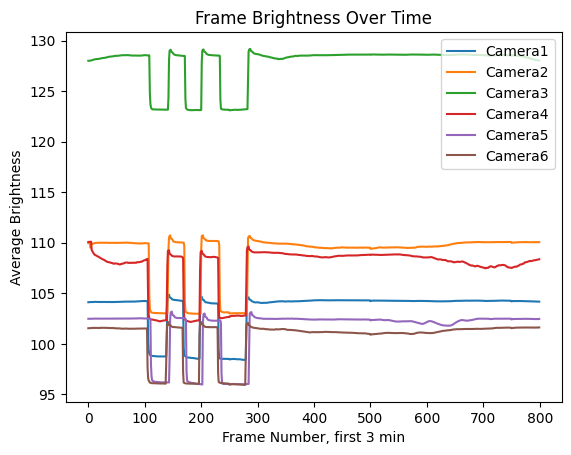

Saved brightness plot to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4/videos/6cam_sync.png
Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4: {'Camera1': [106, 169, 231], 'Camera2': [108, 171, 233], 'Camera3': [109, 172, 234], 'Camera4': [106, 169, 231], 'Camera5': [111, 174, 236], 'Camera6': [105, 168, 230]}
Processed drop frames: {'Camera1': 106, 'Camera2': 108, 'Camera3': 109, 'Camera4': 106, 'Camera5': 111, 'Camera6': 105}
105
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4/df_synced_2025_07_01_0single4_group4_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4 with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single4_group4/2025_

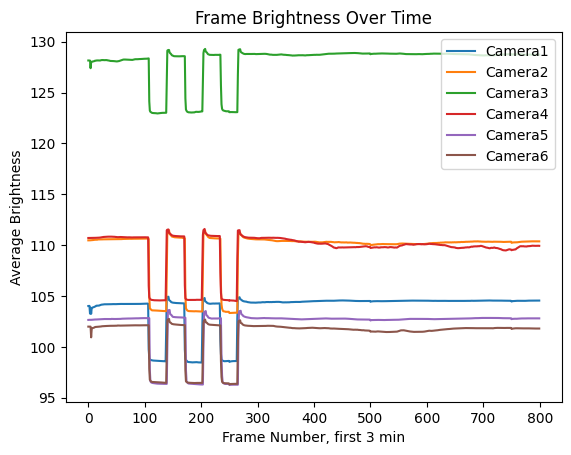

Saved brightness plot to /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5/videos/6cam_sync.png
Detected intensity drop frames in /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5: {'Camera1': [107, 171, 234], 'Camera2': [108, 172, 235], 'Camera3': [108, 172, 235], 'Camera4': [107, 171, 234], 'Camera5': [109, 173, 236], 'Camera6': [108, 172, 235]}
Processed drop frames: {'Camera1': 107, 'Camera2': 108, 'Camera3': 108, 'Camera4': 107, 'Camera5': 109, 'Camera6': 108}
107
alined data saved to: /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5/df_synced_2025_07_01_0single5_group5_calib_before_label3d_dannce.mat
Alignment successful for /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5 with /hpc/group/tdunn/Bryan_Rigs/BigOpenField/minji_social_single_grouphoused/2025_07_01/0single5_group5/2025_

In [6]:
from utlis.exe_engine_utlis.comb_all_exe import sequential_process_and_update_sync

sequential_process_and_update_sync(filtered_table, base_folder, max_frames=800) #threshold=2, max_frames=300, min_frame=0

In [ ]:
# social com

from utlis.exe_engine_utlis.comb_all_exe import dispatch_slurm_jobs

dispatch_slurm_jobs(
    base_path=base_folder,
    table=filtered_table,
    slurm_launch_file="/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict_social.py",
    predict_flag="--predict_com",
    conda_env="sdannce",
    partition="scavenger-gpu",
    dry_run=False,
    max_workers=6,
)

In [ ]:
# single com

from utlis.exe_engine_utlis.comb_all_exe import dispatch_slurm_jobs

dispatch_slurm_jobs(
    base_path=base_folder,
    table=filtered_table,
    slurm_launch_file="/hpc/group/tdunn/lq53/tianqing_pytorch_dannce/dannce_/slurm_launch_predict.py",
    predict_flag="--predict_com",
    conda_env="sdannce",
    partition="scavenger-gpu",
    dry_run=False,
    max_workers=6,
)

In [ ]:
# single com vis

from utlis.vis_valid_utlis.com_trag_updated import plot_com_all

# Assume base_folder is defined elsewhere in your script
# base_folder = '/path/to/your/base/folder'
for_com_vis = filtered_table
records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
for record in records:
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    plot_com_all(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


In [ ]:
# social com vis

# from utlis.vis_valid_utlis.com_trag_updated import plot_com_all
from utlis.vis_valid_utlis.scom_traga_utlis import plot_com_all_social

# Assume base_folder is defined elsewhere in your script
# base_folder = '/path/to/your/base/folder'
for_com_vis = filtered_table
records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_com_vis['date_folder'], for_com_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
for record in records:
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    plot_com_all_social(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False


In [ ]:
# single dannce valid


from useful_files.sophie_check_dannce_mir_modif import dannce_valid

for_dannce_vis = filtered_table


records = [
    {
        'date_folder': date_folder.as_py(),  # Convert to string using as_py()
        'rec_file': rec_file.as_py()         # Convert to string using as_py()
    }
    for date_folder, rec_file in zip(for_dannce_vis['date_folder'], for_dannce_vis['rec_file'])
]

# Iterate through the records and process each one sequentially
# for record in records:
#     base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
#     print(base_path)
#     try:
#         dannce_valid(base_path) #com_folder_name='COM/predict00', perform_jump_indices=True, perform_video_generation=False, perform_generate_com_video=False
#     except Exception as e:
#         print(f" An error occurred while processing {base_path}: {e}")
#         # Skip to the next record if an error occurs
#         continue

# #trying for parallel processing again:
from concurrent.futures import ProcessPoolExecutor, as_completed

def process_record(record):
    base_path = f"{base_folder}/{record['date_folder']}/{record['rec_file']}"
    print(base_path)
    try:
        dannce_valid(base_path)
    except Exception as e:
        print(f"An error occurred while processing {base_path}: {e}")
        # Skip to the next record if an error occurs
        pass

with ProcessPoolExecutor() as executor:
    futures = [executor.submit(process_record, record) for record in records]
    for future in as_completed(futures):
        pass  # You can retrieve results or handle exceptions here if needed
